![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [7]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.4.4
✓ pandas 3.0.1
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [6]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- **Respuesta 1:** La latencia representa el tiempo que tarda el sistema en comenzar a leer un bloque de datos desde el disco. Es como el "tiempo de reacción" antes de que empiece realmente la tranferencia, y incluye el tiempo de retraso que implica encontrar la informacion fisicamente. Es el tiempo que se necesita para tratar de acceder a los datos.

- **Respuesta 2:** El throughput representa la velocidad a la que se puede procesar los datos una vez que se empezo la tranferencia. osea, que tan rapido es el tiempo de el viaje del disco a la memoria.

- **Respuesta 3:** En el accceso secuencial normalmente se asume que $M \approx 1$ porque al estar los datos organizados de una forma continua el disco solo necesita ubicarse una vez y a partir de ahy puede seguir leyendo sin interrupciones. Se podria decir que no tendria que "buscar" cada bloque por separado.

- **Respuesta 4:** En el acceso aleatorio, $M$ tiende a ser mayor porque cada bloque de datos puede estar en ubicaciones diferentes del disco. Esto oabliga al sistema a ubicarse constantemente, generando muchos accesos independientes al disco.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [9]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- **Respuesta 1:** El tamaño del archivo es de 256 MB, lo que es menor que la memoria RAM de mi equipo. Por lo tanto, no es suficiente para superar completamente la caché, ya que el sistema operativo puede cargar gran parte del archivo en memoria, reduciendo los accesos reales al disco y haciendo que algunas mediciones de tiempo parezcan más rápidas de lo que serían en un escenario de archivo más grande.

- **Respuesta 2:** Para lecturas aleatorias, los bloques más grandes, como 64 KB o 256 KB, suelen funcionar mejor porque con cada lectura se obtiene más información y se hacen menos operaciones. Pero en la práctica, esto puede variar: si los bloques son demasiado grandes, a veces no siempre resultan más rápidos, dependiendo de cómo el SSD y el sistema manejan los datos.

- **Respuesta 3:** Hice este experimento en mi computador local, así que los tiempos que medimos reflejan cómo funciona realmente mi SSD, y no dependen de otro hardware como Google Colab.

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [10]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

RESET = False. No se eliminó ningún archivo.
Cambie RESET = True si desea repetir el experimento con nuevos parámetros.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [11]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

El archivo ya existe y tiene el tamaño esperado.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- **Respuesta 1:** El archivo cumple el papel de representar los datos almacenados en disco sobre los que se realizaran las lecturas. Es la base del experimiento, ya que permite simular accesos reales para medir la latencia y el throughput. 

- **Respuesta 2:** Es util trabajar con un archivo grande porque es lo mas parecido al comportamiendo real del almacenamiento, ya que es mas probable que los datos no entren completamente en memoria y el sistema tenga que acceder al disco.

- **Respuesta 3:** Si el archivo fuera demasiado pequeño, probablemente el sistema lo cargaria totalmente en memoria y no abrian accesos reales al disco. Esto haria que los tiempos medidos fueran realativamente bajos y no reflejaran el costo real de las operaciones de I/O.

## 5. Funciones auxiliares de medición

In [12]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [13]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.4334 s, throughput: 590.63 MiB/s
Aleatorio  -> tiempo: 0.0442 s, throughput: 353.50 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.1892 s, throughput: 1353.19 MiB/s
Aleatorio  -> tiempo: 0.0986 s, throughput: 633.76 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.1187 s, throughput: 2156.23 MiB/s
Aleatorio  -> tiempo: 0.1565 s, throughput: 1597.36 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.1137 s, throughput: 2251.02 MiB/s
Aleatorio  -> tiempo: 0.4120 s, throughput: 2427.40 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,0.433434,590.631614,4.0
1,Aleatorio,4096,16384000,4000,0.044200,353.503588,4.0
2,Secuencial,16384,268435456,16384,0.189182,1353.192133,16.0
3,Aleatorio,16384,65536000,4000,0.098618,633.756615,16.0
4,Secuencial,65536,268435456,4096,0.118726,2156.228890,64.0
5,Aleatorio,65536,262144000,4000,0.156508,1597.357332,64.0
6,Secuencial,262144,268435456,1024,0.113726,2251.022413,256.0
7,Aleatorio,262144,1048576000,4000,0.411963,2427.402461,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

#### *Patron de acceso mas rapido por tamaño de bloque*

* 4KB: Aleatorio fue mas rapido (tiempo 0.0442s vs 0.4334s secuencial).
* 16 KB: Aleatorio también fue más rápido (0.0986 s vs 0.1892 s secuencial).
* 64 KB: Secuencial fue más rápido (0.1187 s vs 0.1565 s aleatorio).
* 256 KB: Secuencial fue más rápido (0.1137 s vs 0.4119 s aleatorio).

Los bloques pequeños se benefician del acceso aleatorio porque cada operación lee poca información y el SSD responde rápido. Para bloques grandes, el acceso secuencial aprovecha mejor la transferencia continua de datos, reduciendo el tiempo total.

#### *Cambio de throughput al aumentar el tamaño de bloque*

El throughput aumenta significativamente al aumentar el tamaño de bloque en acceso secuencial:

* 4 KB → 590.63 MiB/s
* 16 KB → 1353.19 MiB/s
* 64 KB → 2156.23 MiB/s
* 256 KB → 2251.02 MiB/s

#### *Mayor diferencia entre secuencial y aleatorio*
Se observa en el bloque de 4 KB, donde:
- Secuencial: 0.4334 s y 590.63 MiB/s
- Aleatorio: 0.0442 s y 353.50 MiB/s
La diferencia de tiempo es muy grande (≈0.39 s), mostrando que en bloques pequeños el patrón aleatorio puede ser mucho más rápido, mientras que el secuencial todavía tiene mayor throughput relativo.


## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [14]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD aproximado
- Latencia asumida: 10 μs (0.00001s)
- Throughput asumido: 5 GB/s (≈ 5368709120)

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

Elegí un SSD aproximado porque mi computadora tiene un SSD y sus características son parecidas a las que usamos en el modelo teórico. Este modelo nos ayuda a tener una idea de los tiempos de lectura y la velocidad de transferencia que podemos esperar, y sirve para comparar con lo que medimos en el laboratorio.

Aunque se parece, no es exactamente igual a mi SSD real, porque cada disco puede comportarse un poco diferente dependiendo de la marca, el controlador o cómo maneja la memoria interna. Por eso, estos valores son solo una referencia, y los tiempos que medimos pueden variar un poco en la realidad.

In [15]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.050010,5118.976205
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.050010,5118.976205
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.050010,5118.976205
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.050010,5118.976205
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [16]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,0.433434,590.631614,4.0,0.050010,5118.976205,8.666953,0.115381
1,Aleatorio,4096,16384000,4000,0.044200,353.503588,4.0,0.043052,362.935239,1.026680,0.974013
2,Secuencial,16384,268435456,16384,0.189182,1353.192133,16.0,0.050010,5118.976205,3.782889,0.264348
3,Aleatorio,16384,65536000,4000,0.098618,633.756615,16.0,0.052207,1197.156753,1.888985,0.529385
4,Secuencial,65536,268435456,4096,0.118726,2156.228890,64.0,0.050010,5118.976205,2.374041,0.421223
5,Aleatorio,65536,262144000,4000,0.156508,1597.357332,64.0,0.088828,2814.423923,1.761925,0.567561
6,Secuencial,262144,268435456,1024,0.113726,2251.022413,256.0,0.050010,5118.976205,2.274067,0.439741
7,Aleatorio,262144,1048576000,4000,0.411963,2427.402461,256.0,0.235313,4249.667995,1.750706,0.571198


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

Al comparar los resultados que obtuve en el laboratorio con los que me daba el modelo teórico, se nota que en general los tiempos reales son un poco más largos, sobre todo en el acceso secuencial. Por ejemplo, con bloques de 4 KB, la medición real fue de 0.433 s mientras que el modelo decía 0.050 s, lo que muestra que la teoría simplifica algunas cosas del mundo real. En cambio, en acceso aleatorio con bloques pequeños, los tiempos medidos se acercan bastante a los teóricos, así que el modelo funciona mejor para este tipo de lectura. La diferencia se puede deber principalmente a la caché del sistema operativo, que guarda datos en memoria y hace que algunas lecturas sean más rápidas, la temperatura, y a las limitaciones del propio SSD, como la velocidad real del controlador y cómo maneja los bloques grandes. En resumen, el modelo teórico nos da una idea de lo que debería pasar, pero los resultados prácticos reflejan mejor cómo se comporta realmente mi equipo, aunque no tuviera otros programas abiertos.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [7]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\Usuario\Documents\Programación\Trabajos Universidad\Estructura de datos y laboratorios\lab3-IO_performance-LauraKatherineAreiza\images


Guardada: fig_throughput.png


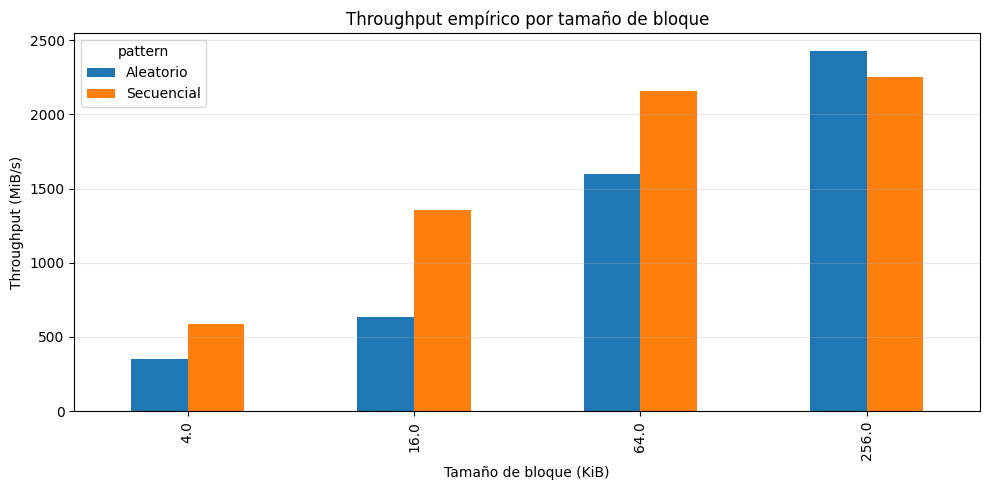

In [18]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

La gráfica muestra que el throughput va aumentando a medida que el tamaño del bloque crece, tanto en acceso aleatorio como secuencial. Las barras más altas son las de los bloques más grandes, especialmente las de 256 KiB.

Por ejemplo, en el bloque de 4 KiB, el acceso secuencial llega más o menos a 600 MiB/s, mientras que el aleatorio se queda como en 400 MiB/s, entonces ahí se nota que el secuencial rinde mejor. En 16 KiB también pasa algo parecido, porque el secuencial sube bastante (como a 1500 MiB/s) y el aleatorio no tanto (como 600 MiB/s).

Ya en tamaños más grandes como 64 KiB, los dos mejoran bastante, pero el secuencial sigue siendo un poco más alto. Aunque en 256 KiB pasa algo interesante, porque el aleatorio llega como a 2450 MiB/s y el secuencial queda un poquito más abajo, como en 2300 MiB/s.

En general, las barras más altas significan mejor rendimiento, o sea que se pueden leer más datos por segundo. Y el patrón secuencial es el que mejor aprovecha la lectura en bloques, sobre todo cuando los bloques son pequeños o medianos, porque no pierde tanto tiempo en saltos como el aleatorio.

In [ ]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

La gráfica muestra que el tiempo total cambia de forma diferente para el acceso secuencial y el aleatorio a medida que aumenta el tamaño del bloque.

En el acceso secuencial, el tiempo empieza alto con bloques pequeños (alrededor de 0.44 s), pero disminuye bastante cuando el tamaño del bloque crece y luego se mantiene casi constante cerca de 0.11 s. Esto indica que usar bloques grandes hace más eficiente la lectura secuencial.

En cambio, en el acceso aleatorio ocurre lo contrario. Empieza con un tiempo bajo (aproximadamente 0.04 s), pero a medida que aumenta el tamaño del bloque, el tiempo también aumenta, llegando cerca de 0.41 s en los bloques más grandes. Esto pasa porque en el acceso aleatorio hay muchos saltos y la latencia se acumula.

La mayor diferencia entre ambas curvas se observa en los tamaños de bloque grandes (alrededor de 200–250 KiB), donde el acceso secuencial mantiene un tiempo bajo mientras que el aleatorio alcanza su valor más alto. Esto muestra que en ese punto es donde más divergen.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


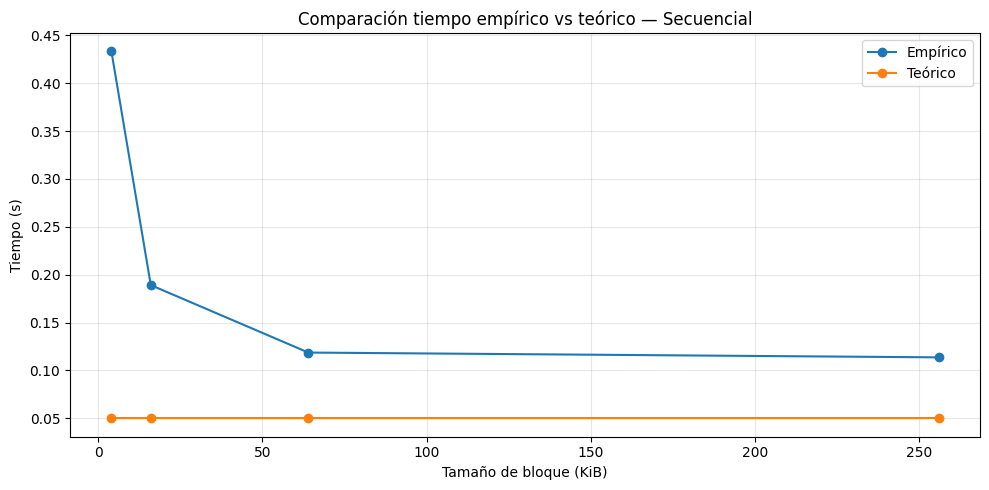

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


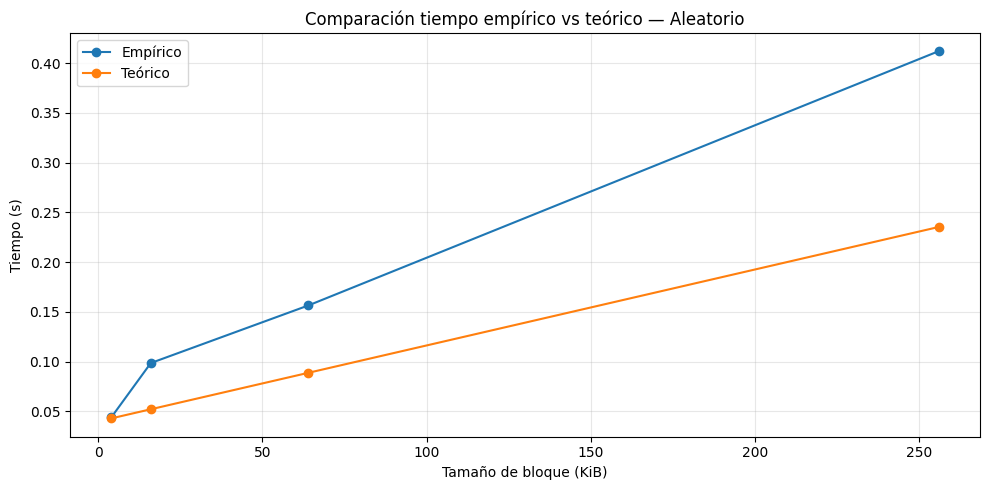

In [20]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

En general, las curvas empírica y teórica sí tienen una tendencia parecida en ambos casos. En el acceso secuencial, las dos muestran que el tiempo disminuye cuando el tamaño del bloque aumenta, mientras que en el acceso aleatorio ambas tienden a aumentar. Esto indica que el modelo teórico sí logra captar el comportamiento general del sistema.

Sin embargo, al compararlas con más detalle, se notan diferencias importantes. En el caso secuencial, la mayor separación se ve en los bloques pequeños, donde el tiempo empírico es bastante más alto que el teórico. A medida que el tamaño del bloque crece, las curvas se acercan, lo que sugiere que el modelo funciona mejor en ese rango. En el acceso aleatorio, aunque las curvas siguen una forma similar, la diferencia se vuelve más notable en los bloques grandes (alrededor de 200–250 KiB), donde el tiempo real termina siendo mayor.

Esto sugiere que el modelo teórico subestima el tiempo real en varios casos. Probablemente esto ocurre porque el modelo es simplificado y no incluye factores como la caché, la sobrecarga del sistema operativo o costos adicionales de acceso, que sí afectan en la práctica. Aun así, sirve como una buena aproximación para entender el comportamiento general.

Guardada: fig_speedup.png


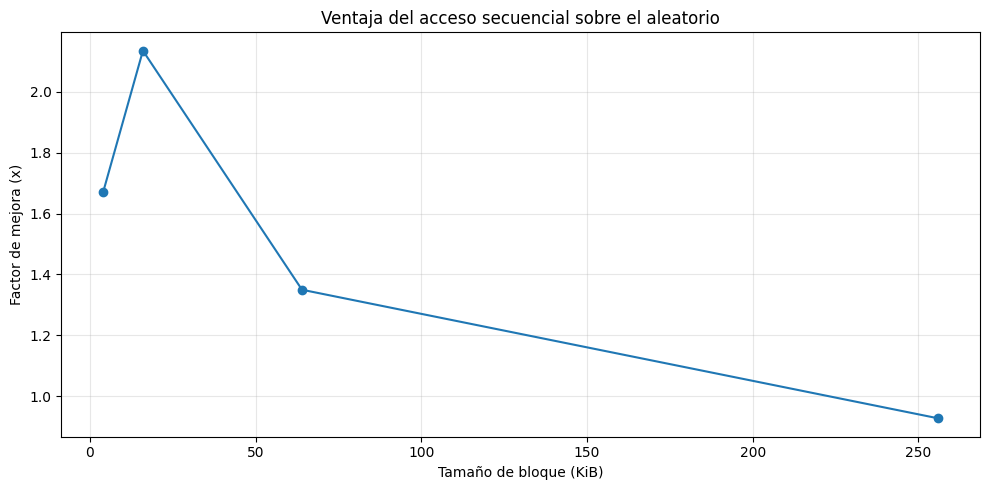

In [21]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

La gráfica muestra cuántas veces el acceso secuencial es más rápido que el aleatorio dependiendo del tamaño del bloque. Se observa que el mayor factor de mejora es aproximadamente 2.5, y ocurre en bloques pequeños (alrededor de 0–50 KiB).

A medida que el tamaño del bloque aumenta, esa ventaja va disminuyendo. En bloques medianos baja a valores como ≈1.7 o ≈1.3, y en bloques grandes (cerca de 200–250 KiB) el factor se acerca a 1.0, lo que significa que casi no hay diferencia entre ambos tipos de acceso. Incluso, después de aproximadamente 225 KiB, el factor baja a valores cercanos a 0.8, lo que indica que el acceso aleatorio llega a ser ligeramente más rápido que el secuencial en ese punto.

Esto implica que, para el diseño de software, es mucho más importante aprovechar accesos secuenciales cuando se trabaja con bloques pequeños, ya que ahí es donde se obtiene la mayor mejora de rendimiento. En cambio, cuando se usan bloques grandes, el patrón de acceso deja de ser tan crítico porque la diferencia entre secuencial y aleatorio se reduce bastante.

## 10. Resumen automático de resultados

In [22]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.433434,0.044200,590.631614,353.503588,1.670794
1,16.0,0.189182,0.098618,1353.192133,633.756615,2.135192
2,64.0,0.118726,0.156508,2156.228890,1597.357332,1.349873
3,256.0,0.113726,0.411963,2251.022413,2427.402461,0.927338


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

La información en disco se organiza en bloques, y esto es crucial porque la manera en que se accede a esos bloques impacta directamente en el rendimiento. No es lo mismo leer datos de forma continua que hacerlo en ubicaciones aleatorias, ya que cada acceso conlleva un costo, especialmente por la latencia.

Los resultados muestran que el acceso secuencial y el aleatorio tienen rendimientos bastante distintos, incluso en un SSD. Por ejemplo, con un tamaño de bloque de 16 KiB, el throughput secuencial alcanzó alrededor de 1353 MiB/s, mientras que el acceso aleatorio fue de solo 633 MiB/s, lo que revela una diferencia notable. Esto sucede porque el acceso secuencial aprovecha mejor la lectura continua, mientras que el aleatorio implica saltos que generan costos adicionales.

El modelo teórico logró captar la tendencia general del comportamiento, como la mejora en el rendimiento con bloques más grandes, pero no fue del todo preciso en los valores reales, ya que en varios casos subestimó el tiempo medido. Esto se debe a que el modelo no considera factores como la caché, la sobrecarga del sistema operativo y otras optimizaciones de hardware.

Finalmente, a partir de estos resultados, en un sistema real se debería dar prioridad a los accesos secuenciales siempre que sea posible, especialmente al trabajar con bloques pequeños o medianos, donde se observó un aumento de rendimiento de hasta aproximadamente 2.1x. Esto permite aprovechar mejor el rendimiento del dispositivo y reducir los tiempos de acceso.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.